In [3]:
import pandas as pd
import pymc as pm
import japanize_matplotlib
import matplotlib.pyplot as plt
import pytensor.tensor as pt
import numpy as np
import arviz as az

In [17]:
df = pd.read_csv("../data/telco_churn_survival.csv")
df_full = pd.read_csv("../data/total_churn.csv")
print(df.isnull().sum())
print(df_full.isnull().sum())
df.head()

customerID        0
tenure            0
Churn             0
Contract          0
MonthlyCharges    0
gender            0
SeniorCitizen     0
event             0
dtype: int64
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


,customerID,tenure,Churn,Contract,MonthlyCharges,gender,SeniorCitizen,event
0,7590-VHVEG,1,No,Month-to-month,29.85,Female,0,0
1,5575-GNVDE,34,No,One year,56.95,Male,0,0
2,3668-QPYBK,2,Yes,Month-to-month,53.85,Male,0,1
3,7795-CFOCW,45,No,One year,42.30,Male,0,0
4,9237-HQITU,2,Yes,Month-to-month,70.70,Female,0,1


In [18]:
df["PaymentMethod"] = df_full["PaymentMethod"]
payment_categories = df["PaymentMethod"].unique()
payment_idx = df["PaymentMethod"].astype("category").cat.codes.values
n_groups = len(payment_categories)

t_obs_safe = df["tenure"].values.astype(float) + 0.5
event_obs = df["event"].values.astype(float)
x1 = (df["Contract"]=="One year").astype(float).values
x2 = (df["Contract"]=="Two year").astype(float).values

breaks = np.arange(0, 78, 6)
n_intervals = len(breaks) - 1
interval_idx = np.clip(np.searchsorted(breaks, t_obs_safe, side="right") -1, 0, n_intervals-1)
exposure = t_obs_safe - breaks[interval_idx]


In [20]:
with pm.Model() as frailty_model:

    h0 = pm.Gamma("h0", alpha=10, beta=10/0.055, shape=n_intervals)
    beta1 = pm.Normal("beta1", mu=0, sigma=1)
    beta2 = pm.Normal("beta2", mu=0, sigma=1)

    alpha_frailty = pm.Gamma("alpha_frailty", alpha=50, beta=50/1)
    z = pm.Gamma("z", alpha=alpha_frailty, beta=alpha_frailty, shape=n_groups)
    
    log_hazard_ratio = beta1 * x1 + beta2 * x2
    h_i = h0[interval_idx] * pt.exp(log_hazard_ratio) * z[payment_idx]

    log_lik = event_obs * pt.log(h_i) - h_i * exposure
    pm.Potential("loglike", pt.sum(log_lik))

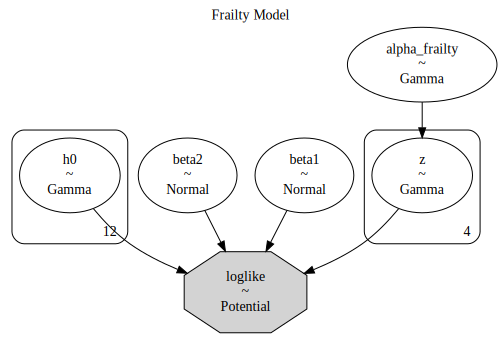

In [22]:
g = pm.model_to_graphviz(frailty_model)
g.graph_attr.update(
    label="Frailty Model",
    labelloc="t",
    fontdize="16"
)
g.render(filename="../models/frailty_model_graph", format="png", cleanup=True)
g

In [24]:
with frailty_model:
    prior = pm.sample_prior_predictive(draws=300, random_seed=42)
prior

/tmp/ipykernel_8188/3970435057.py:2: UserWarning: The effect of Potentials on other parameters is ignored during prior predictive sampling. This is likely to lead to invalid or biased predictive samples.
  prior = pm.sample_prior_predictive(draws=300, random_seed=42)
Sampling: [alpha_frailty, beta1, beta2, h0, z]


<xarray.DataTree>
Group: /
├── Group: /prior
│       Dimensions:        (chain: 1, draw: 300, h0_dim_0: 12, z_dim_0: 4)
│       Coordinates:
│         * chain          (chain) int64 8B 0
│         * draw           (draw) int64 2kB 0 1 2 3 4 5 6 ... 294 295 296 297 298 299
│         * h0_dim_0       (h0_dim_0) int64 96B 0 1 2 3 4 5 6 7 8 9 10 11
│         * z_dim_0        (z_dim_0) int64 32B 0 1 2 3
│       Data variables:
│           h0             (chain, draw, h0_dim_0) float64 29kB 0.02966 ... 0.04621
│           alpha_frailty  (chain, draw) float64 2kB 1.053 0.9974 1.214 ... 1.167 1.136
│           beta2          (chain, draw) float64 2kB -0.1004 1.46 ... -0.5544 0.367
│           z              (chain, draw, z_dim_0) float64 10kB 2.274 0.07261 ... 0.2207
│           beta1          (chain, draw) float64 2kB -0.3433 -1.661 ... -1.326 1.729
│       Attributes:
│           created_at:                 2026-07-16T00:49:01.712861+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.0.1
│           sample_dims:                ['chain', 'draw']
├── Group: /prior_predictive
│       Attributes:
│           created_at:                 2026-07-16T00:49:01.714755+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.0.1
│           sample_dims:                ['chain', 'draw']
└── Group: /observed_data
        Attributes:
            created_at:                 2026-07-16T00:49:01.715323+00:00
            creation_library:           ArviZ
            creation_library_version:   1.2.0
            creation_library_language:  Python
            inference_library:          pymc
            inference_library_version:  6.0.1
            sample_dims:                []

PaymentMethodカテゴリ: ['Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Credit card (automatic)']

z(frailty)の事前分布:
Electronic check: 平均=0.998, sd=0.924
Mailed check: 平均=0.927, sd=0.934
Bank transfer (automatic): 平均=1.061, sd=1.153
Credit card (automatic): 平均=1.070, sd=1.087

alpha_frailty: 平均= 1.00017813926383 範囲=[ 0.5209159629522945 , 1.394033377245936 ]


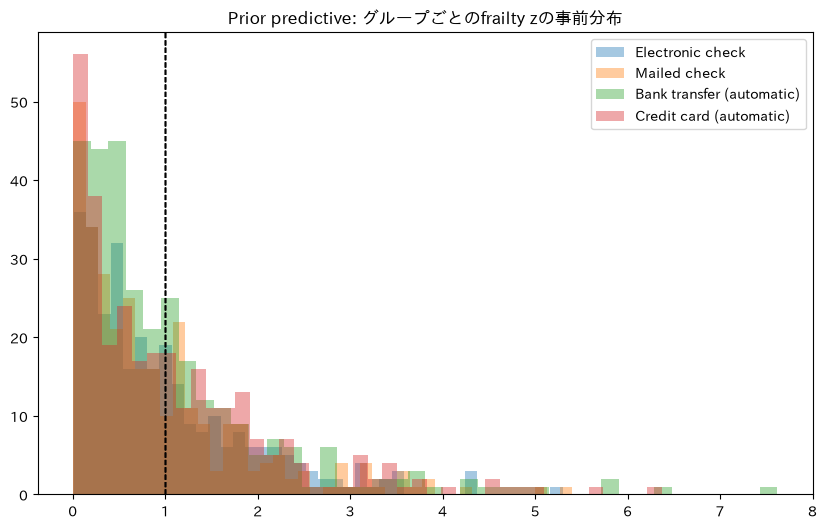

In [25]:
z_prior = prior.prior["z"].values.reshape(-1, n_groups)
alpha_frailty_prior = prior.prior["alpha_frailty"].values.flatten()

print("PaymentMethodカテゴリ:", list(payment_categories))
print("\nz(frailty)の事前分布:")
for g in range(n_groups):
    print(f"{payment_categories[g]}: 平均={z_prior[:, g].mean():.3f}, sd={z_prior[:, g].std():.3f}")
print("\nalpha_frailty: 平均=", alpha_frailty_prior.mean(), "範囲=[", alpha_frailty_prior.min(), ",", alpha_frailty_prior.max(), "]")

fig, ax = plt.subplots(figsize=(10, 6))
for g in range(n_groups):
    ax.hist(z_prior[:, g], bins=40, alpha=0.4, label=str(payment_categories[g]))
    ax.axvline(1.0, color="black", ls="--", lw=1)
    ax.legend()
    ax.set_title("Prior predictive: グループごとのfrailty zの事前分布")
    plt.savefig("../img/frailty_prior_check.png", dpi=100)

In [29]:
#カプランマイヤー曲線
def kaplan_meier(t_obs, event_obs):
    order = np.argsort(t_obs)
    t_sorted = t_obs[order]
    e_sorted = event_obs[order]
    unique_times = np.unique(t_sorted[e_sorted == 1])

    survival = 1.0
    km_times= [0]
    km_surv = [1.0]
    n_at_risk = len(t_obs)

    for t in unique_times:
        n_event = np.sum((t_sorted == t) & (e_sorted == 1))
        n_at_risk = np.sum(t_sorted >= t)
        survival *= (1 - n_event / n_at_risk)
        km_times.append(t)
        km_surv.append(survival)

    return np.array(km_times), np.array(km_surv)

km_t, km_s = kaplan_meier(t_obs_safe, event_obs)

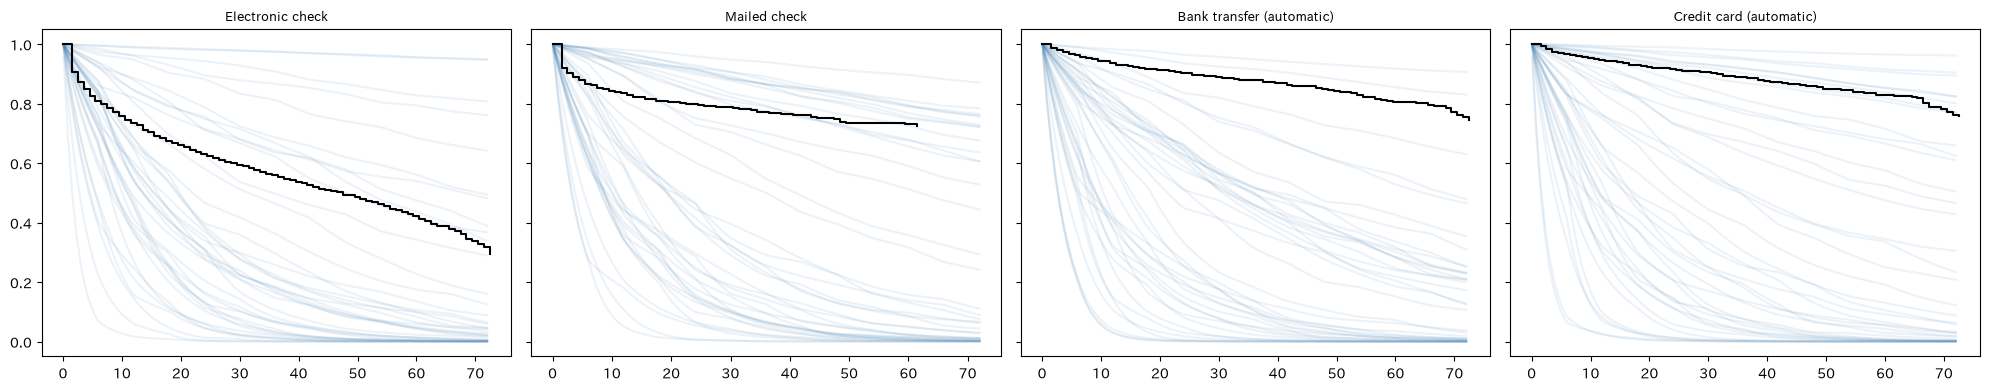

In [30]:
def piecewise_survival_with_frailty(t_range, h0_vals, breaks, z_val):
    S = np.ones_like(t_range)
    cum_hazard = np.zeros_like(t_range)
    for i, t in enumerate(t_range):
        idx = np.clip(np.searchsorted(breaks, t, side="right")-1, 0, len(h0_vals)-1)
        ch = sum(h0_vals[k]*(breaks[k+1]-breaks[k]) for k in range(idx)) * z_val
        ch +=h0_vals[idx] * (t - breaks[idx]) * z_val
        cum_hazard[i] = ch
    return np.exp(-cum_hazard)

h0_prior = prior.prior["h0"].values.reshape(-1, n_intervals)
t_range = np.linspace(0.1, 72, 100)

fig, axes = plt.subplots(1, n_groups, figsize=(20, 4), sharey=True)
for g in range(n_groups):
    mask = (df["PaymentMethod"]==payment_categories[g]).values
    km_t_g, km_s_g = kaplan_meier(t_obs_safe[mask], event_obs[mask])
    for i in range(40):
        S_g = piecewise_survival_with_frailty(t_range, h0_prior[i], breaks, z_prior[i, g])
        axes[g].plot(t_range, S_g, color="steelblue", alpha=0.1)
    axes[g].step(km_t_g, km_s_g, where="post", color="black", lw=1.5,)
    axes[g].set_title(str(payment_categories[g]), fontsize=9)
plt.tight_layout()
plt.savefig("../img/frailty_prior_check_bygroup.png", dpi=100)

In [34]:
with frailty_model:
    idata_frailty = pm.sample(
        draws=2000, tune=2000, chains=4, cores=4,
        target_accept=0.9, nuts_sampler="numpyro", random_seed=42
    )

NUTS[numpyro]: [h0, beta1, beta2, alpha_frailty, z]
Compiling.. :   0%|       | 0/4000 [00:00<?, ?it/s]

  0%|                     | 0/4000 [00:00<?, ?it/s]

Compiling.. :   0%|       | 0/4000 [00:00<?, ?it/s]


  0%|                     | 0/4000 [00:00<?, ?it/s]


Running chain 1:   0%|    | 0/4000 [00:01<?, ?it/s]

Running chain 2:   0%|    | 0/4000 [00:01<?, ?it/s]


Running chain 0:   5%| | 200/4000 [00:01<00:03, 106


Running chain 3:   5%| | 200/4000 [00:01<00:03, 100
Running chain 1:   5%| | 200/4000 [00:01<00:04, 883

Running chain 2:   5%| | 200/4000 [00:01<00:04, 790


Running chain 0:  10%| | 400/4000 [00:01<00:03, 107
Running chain 1:  10%| | 400/4000 [00:01<00:03, 109

Running chain 2:  10%| | 400/4000 [00:01<00:03, 971
Running chain 0:  15%|▏| 600/4000 [00:01<00:03, 109


Running chain 3:  15%|▏| 600/4000 [00:01<00:03, 107

Running chain 2:  15%|▏| 600/4000 [00:01<00:03, 994
Running chain 0:  20%|▏| 800/4000 [00:01<00:02, 115


Running chain 3:  20%|▏| 800/4000 [00:01<00:

In [37]:
print("divergences:", int(idata_frailty.sample_stats["diverging"].sum()))
az.summary(idata_frailty, var_names=["alpha_frailty", "z", "beta1", "beta2"])

divergences: 0


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
alpha_frailty,1.023,0.143,0.81,1.3,10413,5815,1.00,0.0014,0.001
z[0],1.84,0.204,1.5,2.2,1399,2316,1.00,0.0055,0.0042
z[1],1.73,0.194,1.4,2.1,1410,2305,1.00,0.0052,0.0039
z[2],2.76,0.27,2.4,3.2,1104,1856,1.00,0.008,0.006
z[3],1.469,0.164,1.2,1.7,1367,2345,1.00,0.0045,0.0033
beta1,-1.028,0.088,-1.2,-0.89,8169,5943,1.00,0.00097,0.00068
beta2,-2.475,0.167,-2.7,-2.2,7314,5781,1.00,0.002,0.0014


In [40]:
az.summary(idata_frailty, var_names=["h0"])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
h0[0],0.0953,0.0095,0.081,0.11,1176,2115,1.00,0.00027,0.0002
h0[1],0.0655,0.007,0.055,0.077,1383,2494,1.00,0.00019,0.00014
h0[2],0.0674,0.0076,0.056,0.08,1494,2469,1.00,0.0002,0.00015
h0[3],0.0518,0.0064,0.042,0.062,1822,3046,1.00,0.00015,0.00011
h0[4],0.052,0.0066,0.042,0.063,1947,3168,1.00,0.00015,0.00011
h0[5],0.0489,0.0064,0.039,0.059,2074,3075,1.00,0.00014,0.0001
h0[6],0.0544,0.0073,0.043,0.067,2027,3490,1.00,0.00016,0.00012
h0[7],0.0507,0.0072,0.04,0.063,2428,3259,1.00,0.00014,0.00011
h0[8],0.0519,0.0074,0.041,0.064,2594,3403,1.00,0.00014,0.00011
h0[9],0.0541,0.0081,0.042,0.068,2800,4048,1.00,0.00015,0.00011


In [42]:
#zの総和を1にそろえるために幾何平均にする
with pm.Model() as frailty_model_v1:

    h0 = pm.Gamma("h0", alpha=10, beta=10/0.055, shape=n_intervals)
    beta1 = pm.Normal("beta1", mu=0, sigma=1)
    beta2 = pm.Normal("beta2", mu=0, sigma=1)

    sigma_frailty = pm.Gamma("sigma_frailty", alpha=50, beta=50/0.5)

    log_z_raw = pm.Normal("log_z_raw", mu=0, sigma=sigma_frailty, shape=n_groups)
    z = pm.Deterministic("z", pt.exp(log_z_raw) / pt.mean(pt.exp(log_z_raw)))
    
    log_hazard_ratio = beta1 * x1 + beta2 * x2
    h_i = h0[interval_idx] * pt.exp(log_hazard_ratio) * z[payment_idx]

    log_lik = event_obs * pt.log(h_i) - h_i * exposure
    pm.Potential("loglike", pt.sum(log_lik))

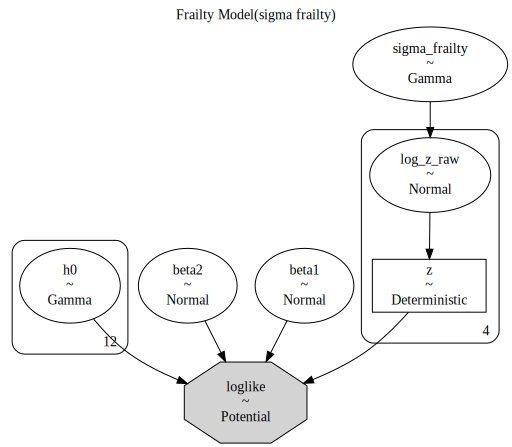

In [46]:
g = pm.model_to_graphviz(frailty_model_v1)
g.graph_attr.update(
    label="Frailty Model(sigma frailty)",
    labelloc="t",
    fontdize="16"
)
g.render(filename="../models/frailty_model_graph_v1", format="png", cleanup=True)
g

In [47]:
with frailty_model_v1:
    idata_frailty = pm.sample(
        draws=2000, tune=2000, chains=4, cores=4,
        target_accept=0.9, nuts_sampler="numpyro", random_seed=42
    )

NUTS[numpyro]: [h0, beta1, beta2, sigma_frailty, log_z_raw]
Compiling.. :   0%|       | 0/4000 [00:00<?, ?it/s]

  0%|                     | 0/4000 [00:00<?, ?it/s]

Compiling.. :   0%|       | 0/4000 [00:00<?, ?it/s]


  0%|                     | 0/4000 [00:00<?, ?it/s]


Running chain 1:   0%|    | 0/4000 [00:01<?, ?it/s]

Running chain 2:   0%|    | 0/4000 [00:01<?, ?it/s]


Running chain 3:   0%|    | 0/4000 [00:01<?, ?it/s]

Running chain 2:   5%| | 200/4000 [00:01<00:03, 101
Running chain 1:   5%| | 200/4000 [00:01<00:05, 748


Running chain 0:   5%| | 200/4000 [00:01<00:05, 684

Running chain 2:  10%| | 400/4000 [00:01<00:04, 872
Running chain 0:  10%| | 400/4000 [00:01<00:05, 667


Running chain 3:  10%| | 400/4000 [00:01<00:06, 584

Running chain 2:  15%|▏| 600/4000 [00:01<00:04, 721
Running chain 0:  15%|▏| 600/4000 [00:02<00:05, 659


Running chain 3:  15%|▏| 600/4000 [00:02<00:05, 601
Running chain 1:  20%|▏| 800/4000 [00:02<00:04, 753

Running chain 0:  20%|▏| 800/4000 [00

In [49]:
print("divergences:", int(idata_frailty.sample_stats["diverging"].sum()))
az.summary(idata_frailty, var_names=["sigma_frailty", "z", "beta1", "beta2"])

divergences: 0


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
sigma_frailty,0.481,0.0683,0.38,0.59,12897,5924,1.00,0.0006,0.00044
z[0],0.928,0.0473,0.85,1,7844,5960,1.00,0.00053,0.00038
z[1],0.867,0.0478,0.79,0.95,8029,5789,1.00,0.00053,0.00038
z[2],1.4609,0.0443,1.4,1.5,8627,5840,1.00,0.00048,0.00034
z[3],0.7438,0.0387,0.68,0.81,8187,4593,1.00,0.00043,0.00031
beta1,-0.893,0.086,-1,-0.76,11062,6613,1.00,0.00082,0.00058
beta2,-2.287,0.165,-2.6,-2,9675,6363,1.00,0.0017,0.0012


In [50]:
az.summary(idata_frailty, var_names=["h0"])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
h0[0],0.1776,0.0072,0.17,0.19,14571,6090,1.00,6e-05,4.3e-05
h0[1],0.1195,0.00765,0.11,0.13,15993,5484,1.00,6e-05,4.3e-05
h0[2],0.1209,0.0087,0.11,0.14,14014,5603,1.00,7.4e-05,5.2e-05
h0[3],0.0918,0.0082,0.079,0.11,13102,6049,1.00,7.2e-05,5e-05
h0[4],0.0909,0.0089,0.077,0.11,14692,5829,1.00,7.4e-05,5.2e-05
h0[5],0.0849,0.00849,0.072,0.099,15164,5811,1.00,6.9e-05,4.8e-05
h0[6],0.0923,0.01,0.077,0.11,14221,5913,1.00,8.4e-05,6.2e-05
h0[7],0.0852,0.0101,0.07,0.1,14234,5316,1.00,8.4e-05,6e-05
h0[8],0.0856,0.0103,0.07,0.1,13260,5939,1.00,8.9e-05,6.4e-05
h0[9],0.0881,0.0109,0.071,0.11,13141,6094,1.00,9.5e-05,6.6e-05


# Telco Churn Frailty Model(生存時間分析の発展) セッションサマリー

## 目的

生存時間分析3大モデル(Exponential/Weibull/Cox)完走後の発展形として、**観測されないグループ特有の"解約しやすさ"**を階層ベイズ的に組み込むFrailty modelに取り組んだ。「あまり習得できた気がしない」という率直な振り返りをきっかけに、これまでの階層ベイズ(MLB/サメ/ポケモン)の知見と生存時間分析を接続する形で理解を深める回となった。

## モデル構造

$$h(t|x,g) = h_{0,k(t)}\times\exp(x^\top\beta)\times z_g, \qquad z_g\sim\text{Gamma}(\alpha_{frailty},\alpha_{frailty})$$

- $g$: `PaymentMethod`(4カテゴリ、Cox単体モデルと違いグループ数が十分あるものを選定)によるグループ分け
- $z_g$: グループ固有の"frailty"(観測されない解約しやすさの倍率)
- グループ選定の議論: 当初`SeniorCitizen`(2値)が候補に挙がったが、部分プーリングの効果を実感するにはグループ数が少なすぎることを指摘し、4カテゴリで分布も比較的均等な`PaymentMethod`に変更。

## 非識別性の発見と対処(このセッションの核心)

### 問題: h0とzの間のスケール非識別性

$z\sim\text{Gamma}(\alpha_{frailty},\alpha_{frailty})$(平均1)という設計にもかかわらず、事後の4グループの$z$の平均が約1.95と、大きく1から外れる結果になった。$h_0$の事後値を前回のCoxモデル単体と比較したところ、**ほぼ正確に半分**(0.197→0.095)になっており、$h_0\times z$という積の中で「$h_0$が縮み、$z$が同じ比率で膨張する」という、SVモデルの2-factor、Hawkes過程のκ/βと同型のスケール非識別性が起きていたことを特定した。

原因: 事前分布で「各$z_g$の周辺期待値が1」であることを保証しても、「サンプリングされた4つの$z_g$の実現値の平均が1になる」ことは保証されない。この差が、$h_0$との間の自由度を生んだ。

### 対処: 制約による構造的な解消

$z$を直接Gammaからサンプルする代わりに、対数正規分布からのサンプルを**事後的に正規化**する形に変更:

$$\log z_{raw,g}\sim N(0,\sigma_{frailty}), \qquad z_g = \frac{\exp(\log z_{raw,g})}{\text{mean}(\exp(\log z_{raw,\cdot}))}$$

この正規化により、$z$の4値の(算術)平均が**サンプリングのたびに強制的に1**になり、$h_0$との間のスケール自由度が数式的に排除された。$\alpha_{frailty}$(Gamma分布の集中度)というパラメータは、$\sigma_{frailty}$(対数正規分布の標準偏差)という役割に置き換わった。

### 対処後の結果

- $h_0$がCoxモデル単体の値(0.197系)にほぼ正確に回帰
- $z$の4グループの平均が1.0に収束
- ess_bulkが7,000〜9,000超まで改善(非識別性の解消がサンプリング効率自体も向上させた)

## Frailtyの解釈

| PaymentMethod | z(事後平均) | 解釈 |
|---|---|---|
| Bank transfer (automatic) | 1.461 | 最も解約しやすい(観測されない要因) |
| Electronic check | 0.928 | ほぼ平均的 |
| Mailed check | 0.867 | やや解約しにくい |
| Credit card (automatic) | 0.744 | 最も解約しにくい |

「自動引き落としだから解約しにくい」という単純な直感には反し、**Bank transferが最も解約しやすいグループ**という結果に。ユーザーの仮説(残高不足による強制解約が、自発的意志によらず`Churn`イベントとして記録されている可能性)は、実データの`Churn`列がイベントの"理由"を区別しない以上、統計的には検証できないが、もっともらしい解釈仮説として記録。この順位関係は非識別性の解消前後で一貫しており、頑健な発見と言える。

Contractの効果($\beta_1,\beta_2$)は、frailty導入前後でほぼ変わらず(-1.02→-0.89、-2.48→-2.29)、ContractとPaymentMethodが独立した情報を捉えていたことを示す、良い頑健性チェックとなった。

---

## 主要な学び

1. **積の形で組み込まれるパラメータには、常にスケール非識別性のリスクがある**: $h_0\times z$という掛け算の構造は、SVモデルの$\sigma_{fast}\times w_{fast}$、Hawkes過程の$\kappa\times e^{-\beta t}$と本質的に同じ危険性を持つ。「周辺分布の期待値を1に固定する」だけでは不十分で、「サンプルの実現値そのものを制約で縛る」(正規化)という、一段強い対処が必要な場合がある。
2. **グループ数の少ない変数は、階層ベイズ・Frailty modelの題材として不向き**: 部分プーリングの効果を実感するには、グループ数がある程度多く、サンプルサイズにもある程度のばらつきがある変数を選ぶ必要がある。2値変数(SeniorCitizen)より4カテゴリ(PaymentMethod)を選んだ判断が、最終的に意味のある結果につながった。
3. **非識別性の解消は、パラメータの絶対値だけでなくサンプリング効率にも表れる**: 対処前後でess_bulkが大きく改善したことは、「見た目のr_hat/divergencesが健全でも、非識別性がサンプリングの質に影を落としている」ことがある、という実例になった。
4. **統計的に検証できない解釈仮説は、そのまま記録しつつ限界を明示する**: 「Bank transferの解約しやすさ」に対する「残高不足による強制解約」という仮説は、データの構造上検証不可能だが、もっともらしい説明として提示しつつ、それが仮説の域を出ないことを明記する姿勢を維持した。

## 生存時間分析シリーズ全体の位置づけ

Exponential→Weibull→Cox(Piecewise Exponential)→Frailty modelという流れを通じ、「ハザードの時間依存性」(Weibull)と「観測されないグループ差」(Frailty)という、2つの独立した拡張軸を扱った。MLB/サメ/ポケモンで培った階層ベイズの技法(平均・集中度への再パラメータ化、shrinkage、非識別性の診断と解消)が、全く異なるジャンルである生存時間分析にもそのまま応用できることを、具体的な非識別性の発見と解消というプロセスを通じて確認できた。
